In [1]:
import os, json
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from PIL import Image, ImageEnhance
import cv2
from tqdm import tqdm

In [2]:
json_path = "photos.json"
photo_dir = "photos"
output_dir = "processed"
os.makedirs(output_dir, exist_ok=True)

In [3]:
with open(json_path, 'r') as f:
    records = [json.loads(line) for line in f]

df = pd.DataFrame(records)
df['image_path'] = df['photo_id'].apply(lambda x: os.path.join(photo_dir, x + ".jpg"))

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

In [6]:
train_df.to_csv(os.path.join(output_dir, "train_meta.csv"), index=False)
test_df.to_csv(os.path.join(output_dir, "test_meta.csv"), index=False)

In [7]:
def preprocess_image(img_path, augment=False):
    try:
        img = Image.open(img_path).convert("RGB")
        img = img.resize((128, 128))
        img_np = np.array(img)

        # Histogram Equalization on Y channel
        img_yuv = cv2.cvtColor(img_np, cv2.COLOR_RGB2YUV)
        img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
        img_eq = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

        # Gaussian Blur
        img_blur = cv2.GaussianBlur(img_eq, (5, 5), 0)

        # Intensity Threshold (on grayscale)
        gray = cv2.cvtColor(img_blur, cv2.COLOR_RGB2GRAY)
        _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_TOZERO)
        img_final = cv2.merge([thresh] * 3)

        # Back to PIL
        img_pil = Image.fromarray(img_final)

        # Augmentation (only for training)
        if augment:
            if np.random.rand() > 0.5:
                img_pil = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
            img_pil = ImageEnhance.Brightness(img_pil).enhance(np.random.uniform(0.9, 1.1))

        return img_pil
    except:
        return None

In [8]:
def process_and_save(df, split):
    out_dir = os.path.join(output_dir, split)
    os.makedirs(out_dir, exist_ok=True)

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split}"):
        label = row['label']
        img_path = row['image_path']
        save_dir = os.path.join(out_dir, label)
        os.makedirs(save_dir, exist_ok=True)

        img = preprocess_image(img_path, augment=(split == "train"))
        if img:
            save_path = os.path.join(save_dir, row['photo_id'] + ".jpg")
            img.save(save_path, "JPEG", quality=85)

In [9]:
process_and_save(train_df, "train")
process_and_save(test_df, "test")

Processing test: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40020/40020 [04:41<00:00, 142.27it/s]


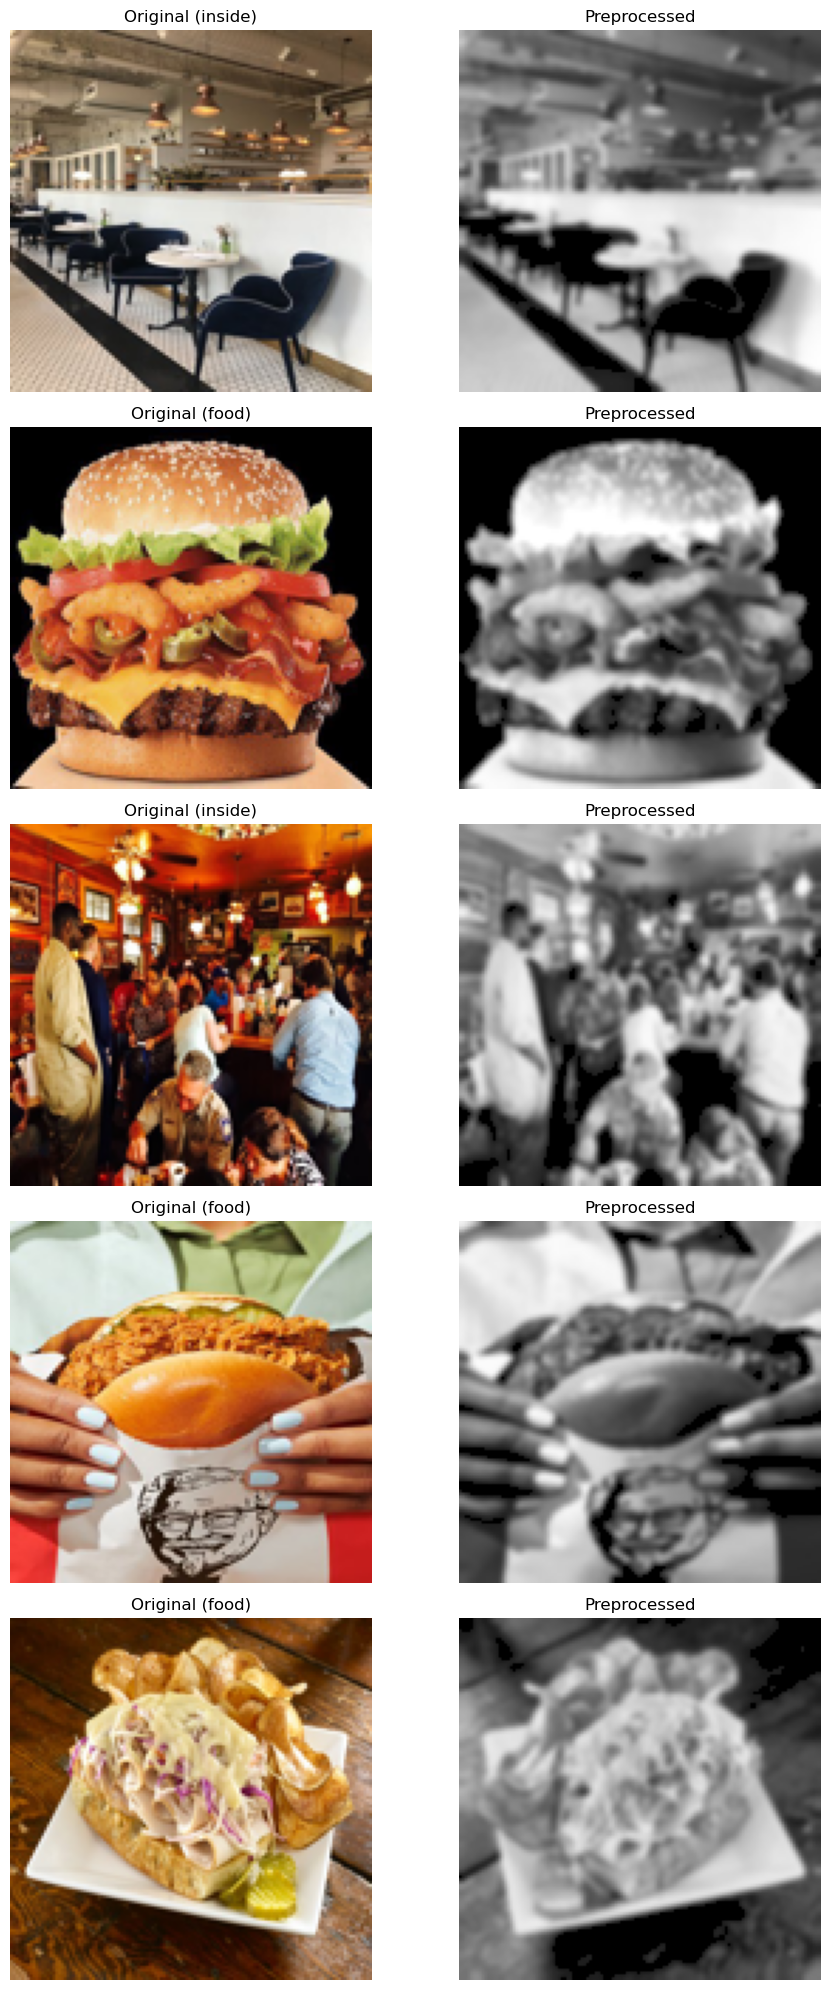

In [16]:
import matplotlib.pyplot as plt

def visualize(df, n=5):
    samples = df.sample(n)
    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))

    for i, (_, row) in enumerate(samples.iterrows()):
        original = Image.open(row['image_path']).convert("RGB").resize((128, 128))
        processed = preprocess_image(row['image_path'], augment=True)

        axes[i, 0].imshow(original)
        axes[i, 0].set_title(f"Original ({row['label']})")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(processed)
        axes[i, 1].set_title("Preprocessed")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

visualize(train_df)